In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
!pip install scipy
from scipy import stats


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install --quiet scikit-learn   


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pd.set_option('display.max_columns', 1000)
plt.style.use('seaborn-v0_8-whitegrid')
from sklearn.model_selection import train_test_split    
from sklearn.linear_model import LinearRegression   
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df = pd.read_csv(r'c:\Users\User\Downloads\sample_data_uk_pet_insurance_quotes.csv')
df.head()

,Id,RiskId,Provider,Species,AnnualPremium,ClaimLimit,AnnualClaimLimit,ExcessLimit,ExcessCoPaymentLimit,UkOnlyCallCentres,DeathByAccident,BoardingFees,LostOrStolen,AdvertisingLimit,ThirdPartyLiability,ThirdPartyLiabilityExcess,HourClaimsService24,VetAdviceLine,LegalAdvice,CoverCategory,CoverStartDate,BereavementCounselling,DeathByIllness,QuarantineCosts,LossOfPetPassport,SetUpFees,AdjustmentFee,DuplicateDocumentsFee,CancellationFee,RenewalFee,TimeStamp,VetFees,VetFeesExcess,MonthlyPremiumInstalment,NumberOfMonthlyInstalments,InstalmentDeposit
0,17083559,FIX3946,4PawsPetInsurance,Dog,323.95,No limit,"£4,000",£105,30%,True,£500,£500,£500,£500,"£2,000,000",£250,True,True,True,NaN,2023-03-06,False,£500,"£1,500","£1,500",0,0,0,0,15,2023-03-05 12:06:25,NaN,NaN,NaN,NaN,NaN
1,282047527,FIX3946,Animal Friends,Dog,112.08,"£2,000","£7,000",£159,NaN,True,£750,£750,£750,£200,"£2,000,000",£250,True,True,False,Time Limited,2024-11-10,False,£750,False,False,0,0,0,0,0,2024-11-09 00:23:14,"Covered for up to £2,000 per condition with £7...",You'll pay £159 per condition,9.34,12.0,0.0
2,282047528,FIX3946,Animal Friends,Dog,115.56,"£2,000",Unlimited,£199,NaN,True,£750,£750,£750,£200,"£2,000,000",£250,True,True,False,Lifetime,2024-11-10,False,£750,False,False,0,0,0,0,0,2024-11-09 00:23:14,"Covered each year up to £2,000 per condition w...",You'll pay £199 per condition per year,9.63,12.0,0.0
3,282047529,FIX3946,Animal Friends,Dog,179.40,"£4,000",Unlimited,£199,NaN,True,"£1,000","£1,000","£1,000",£200,"£2,000,000",£250,True,True,False,Lifetime,2024-11-10,False,"£1,000",False,False,0,0,0,0,0,2024-11-09 00:23:14,"Covered each year up to £4,000 per condition w...",You'll pay £199 per condition per year,14.95,12.0,0.0
4,282047530,FIX3946,Animal Friends,Dog,174.60,"£4,000","£10,000",£159,NaN,True,"£1,000","£1,000","£1,000",£200,"£2,000,000",£250,True,True,False,Time Limited,2024-11-10,False,"£1,000",False,False,0,0,0,0,0,2024-11-09 00:23:14,"Covered for up to £4,000 per condition with £1...",You'll pay £159 per condition,14.55,12.0,0.0


In [8]:
print(f'Shape of the data: {df.shape}')
print(f'There are {df.shape[0]} rows in the data.')

Shape of the data: (7180, 36)
There are 7180 rows in the data.


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7180 entries, 0 to 7179
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          7180 non-null   int64  
 1   RiskId                      7180 non-null   str    
 2   Provider                    7180 non-null   str    
 3   Species                     7180 non-null   str    
 4   AnnualPremium               7180 non-null   float64
 5   ClaimLimit                  7180 non-null   str    
 6   AnnualClaimLimit            7159 non-null   str    
 7   ExcessLimit                 7180 non-null   str    
 8   ExcessCoPaymentLimit        1898 non-null   str    
 9   UkOnlyCallCentres           7180 non-null   bool   
 10  DeathByAccident             7180 non-null   str    
 11  BoardingFees                7180 non-null   str    
 12  LostOrStolen                7180 non-null   str    
 13  AdvertisingLimit            7180 non-null   

In [10]:
df_original = df.copy()
df = df.dropna()

In [11]:
df = df_original.copy()

In [12]:
df.dtypes.unique()

array([dtype('int64'), <StringDtype(storage='python', na_value=nan)>,
       dtype('float64'), dtype('bool')], dtype=object)

In [13]:
g = df.columns.to_series().groupby(df.dtypes.astype(str)).groups
g

{'bool': ['UkOnlyCallCentres', 'HourClaimsService24', 'VetAdviceLine', 'LegalAdvice', 'BereavementCounselling'], 'float64': ['AnnualPremium', 'MonthlyPremiumInstalment', 'NumberOfMonthlyInstalments', 'InstalmentDeposit'], 'int64': ['Id', 'SetUpFees', 'AdjustmentFee', 'DuplicateDocumentsFee', 'CancellationFee', 'RenewalFee'], 'str': ['RiskId', 'Provider', 'Species', 'ClaimLimit', 'AnnualClaimLimit', 'ExcessLimit', 'ExcessCoPaymentLimit', 'DeathByAccident', 'BoardingFees', 'LostOrStolen', 'AdvertisingLimit', 'ThirdPartyLiability', 'ThirdPartyLiabilityExcess', 'CoverCategory', 'CoverStartDate', 'DeathByIllness', 'QuarantineCosts', 'LossOfPetPassport', 'TimeStamp', 'VetFees', 'VetFeesExcess']}

In [14]:
dt = {k: v for k, v in g.items()}

In [15]:
df.isnull().any()

Id                            False
RiskId                        False
Provider                      False
Species                       False
AnnualPremium                 False
ClaimLimit                    False
AnnualClaimLimit               True
ExcessLimit                   False
ExcessCoPaymentLimit           True
UkOnlyCallCentres             False
DeathByAccident               False
BoardingFees                  False
LostOrStolen                  False
AdvertisingLimit              False
ThirdPartyLiability            True
ThirdPartyLiabilityExcess      True
HourClaimsService24           False
VetAdviceLine                 False
LegalAdvice                   False
CoverCategory                  True
CoverStartDate                False
BereavementCounselling        False
DeathByIllness                False
QuarantineCosts               False
LossOfPetPassport             False
SetUpFees                     False
AdjustmentFee                 False
DuplicateDocumentsFee       

In [16]:
df.isnull().sum()

Id                               0
RiskId                           0
Provider                         0
Species                          0
AnnualPremium                    0
ClaimLimit                       0
AnnualClaimLimit                21
ExcessLimit                      0
ExcessCoPaymentLimit          5282
UkOnlyCallCentres                0
DeathByAccident                  0
BoardingFees                     0
LostOrStolen                     0
AdvertisingLimit                 0
ThirdPartyLiability             13
ThirdPartyLiabilityExcess       13
HourClaimsService24              0
VetAdviceLine                    0
LegalAdvice                      0
CoverCategory                  659
CoverStartDate                   0
BereavementCounselling           0
DeathByIllness                   0
QuarantineCosts                  0
LossOfPetPassport                0
SetUpFees                        0
AdjustmentFee                    0
DuplicateDocumentsFee            0
CancellationFee     

In [17]:
df = df.dropna(axis=1)

In [18]:
df.isnull().sum()

Id                        0
RiskId                    0
Provider                  0
Species                   0
AnnualPremium             0
ClaimLimit                0
ExcessLimit               0
UkOnlyCallCentres         0
DeathByAccident           0
BoardingFees              0
LostOrStolen              0
AdvertisingLimit          0
HourClaimsService24       0
VetAdviceLine             0
LegalAdvice               0
CoverStartDate            0
BereavementCounselling    0
DeathByIllness            0
QuarantineCosts           0
LossOfPetPassport         0
SetUpFees                 0
AdjustmentFee             0
DuplicateDocumentsFee     0
CancellationFee           0
RenewalFee                0
TimeStamp                 0
dtype: int64

In [19]:
df['CoverStartDate'] = pd.to_datetime(df['CoverStartDate'])
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].describe()

,Id,AnnualPremium,SetUpFees,AdjustmentFee,DuplicateDocumentsFee,CancellationFee,RenewalFee
count,7.180000e+03,7180.000000,7180.000000,7180.000000,7180.0,7180.000000,7180.000000
mean,1.963055e+08,362.155685,0.106964,0.936630,0.0,1.274373,1.300557
std,9.861562e+07,678.963529,0.918905,2.807274,0.0,6.050807,4.151159
min,6.255560e+06,42.650000,0.000000,0.000000,0.0,0.000000,0.000000
25%,8.797245e+07,150.127500,0.000000,0.000000,0.0,0.000000,0.000000
50%,2.695240e+08,224.040000,0.000000,0.000000,0.0,0.000000,0.000000
75%,2.695312e+08,356.057500,0.000000,0.000000,0.0,0.000000,0.000000
max,2.820477e+08,13616.550000,8.000000,10.000000,0.0,30.000000,18.000000


In [22]:
df.describe()

,Id,AnnualPremium,CoverStartDate,SetUpFees,AdjustmentFee,DuplicateDocumentsFee,CancellationFee,RenewalFee,TimeStamp
count,7.180000e+03,7180.000000,7180,7180.000000,7180.000000,7180.0,7180.000000,7180.000000,7180
mean,1.963055e+08,362.155685,2024-03-24 10:36:22.061281,0.106964,0.936630,0.0,1.274373,1.300557,2024-03-23 19:07:49.075487
min,6.255560e+06,42.650000,2023-01-23 00:00:00,0.000000,0.000000,0.0,0.000000,0.000000,2023-01-22 13:27:35
25%,8.797245e+07,150.127500,2023-08-08 00:00:00,0.000000,0.000000,0.0,0.000000,0.000000,2023-08-07 19:40:41
50%,2.695240e+08,224.040000,2024-09-09 00:00:00,0.000000,0.000000,0.0,0.000000,0.000000,2024-09-08 03:12:38
75%,2.695312e+08,356.057500,2024-09-09 00:00:00,0.000000,0.000000,0.0,0.000000,0.000000,2024-09-08 03:39:33
max,2.820477e+08,13616.550000,2024-11-10 00:00:00,8.000000,10.000000,0.0,30.000000,18.000000,2024-11-09 00:23:14
std,9.861562e+07,678.963529,NaN,0.918905,2.807274,0.0,6.050807,4.151159,NaN


In [23]:

def summary(x):
    x_min = df[x].min()
    x_max = df[x].max()
    Q1 = df[x].quantile(0.25)
    Q2 = df[x].quantile(0.50)
    Q3 = df[x].quantile(0.75)
    print(f'5 Point Summary of {x.capitalize()} Attribute:\n'
          f'{x.capitalize()}(min) : {x_min}\n'
          f'Q1                    : {Q1}\n'
          f'Q2(Median)            : {Q2}\n'
          f'Q3                    : {Q3}\n'
          f'{x.capitalize()}(max) : {x_max}')

    fig = plt.figure(figsize=(16, 10))
    plt.subplots_adjust(hspace = 0.6)
    sns.set_palette('pastel')
    
    plt.subplot(221)
    ax1 = sns.distplot(data[x], color = 'r')
    plt.title(f'{x.capitalize()} Density Distribution')
    
    plt.subplot(222)
    ax2 = sns.violinplot(x = data[x], palette = 'Accent', split = True)
    plt.title(f'{x.capitalize()} Violinplot')
    
    plt.subplot(223)
    ax2 = sns.boxplot(x=data[x], palette = 'cool', width=0.7, linewidth=0.6)
    plt.title(f'{x.capitalize()} Boxplot')
    
    plt.subplot(224)
    ax3 = sns.kdeplot(data[x], cumulative=True)
    plt.title(f'{x.capitalize()} Cumulative Density Distribution')
    
    plt.show()

In [24]:

def box_plot(x = 'bmi'):
    def add_values(bp, ax):
       
        for element in ['whiskers', 'medians', 'caps']:
            for line in bp[element]:
              
                (x_l, y),(x_r, _) = line.get_xydata()
                
                if not np.isnan(y): 
                    x_line_center = x_l + (x_r - x_l)/2
                    y_line_center = y 
                    ax.text(x_line_center, y_line_center, 
                            '%.2f' % y, 
                            verticalalignment='center', 
                            fontsize=12, backgroundcolor="white")

    fig, axes = plt.subplots(1, figsize=(4, 8))

    red_diamond = dict(markerfacecolor='r', marker='D')

    bp_dict = df.boxplot(column = x, 
                             grid=True, 
                             figsize=(4, 8), 
                             ax=axes, 
                             vert = True, 
                             notch=False, 
                             widths = 0.7, 
                             showmeans = True, 
                             whis = 1.5,
                             flierprops = red_diamond,
                             boxprops= dict(linewidth=3.0, color='black'),
                             whiskerprops=dict(linewidth=3.0, color='black'),
                             return_type = 'dict')

    add_values(bp_dict, axes)

    plt.title(f'{x.capitalize()} Boxplot', fontsize=16)
    plt.ylabel(f'{x.capitalize()}', fontsize=14)
    plt.show()
    
    skew = df[x].skew()
    Q1 = df[x].quantile(0.25)
    Q3 = df[x].quantile(0.75)
    IQR = Q3 - Q1
    total_outlier_num = ((df[x] < (Q1 - 1.5 * IQR)) | (df[x] > (Q3 + 1.5 * IQR))).sum()
    print(f'Mean {x.capitalize()} = {df[x].mean()}')
    print(f'Median {x.capitalize()} = {df[x].median()}')
    print(f'Skewness of {x}: {skew}.')
    print(f'Total number of outliers in {x} distribution: {total_outlier_num}.')   

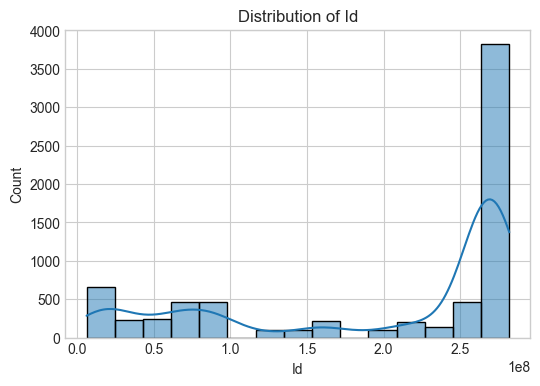

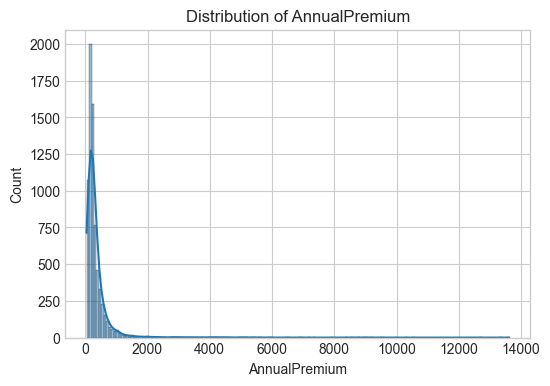

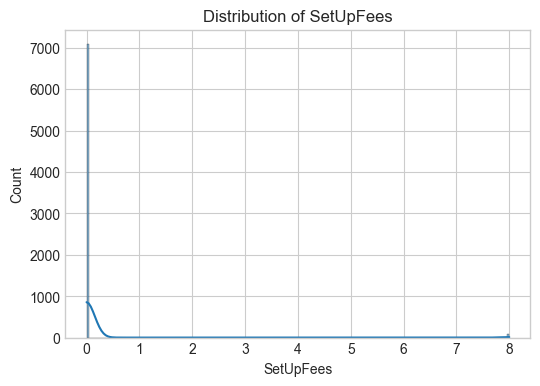

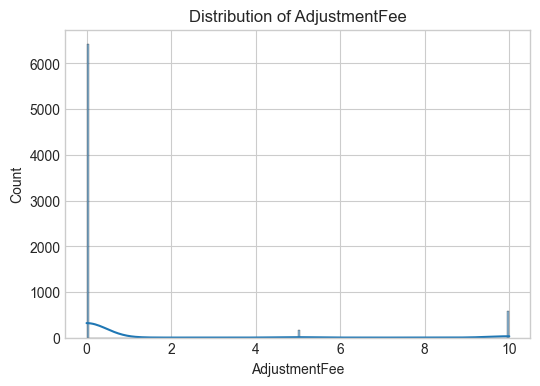

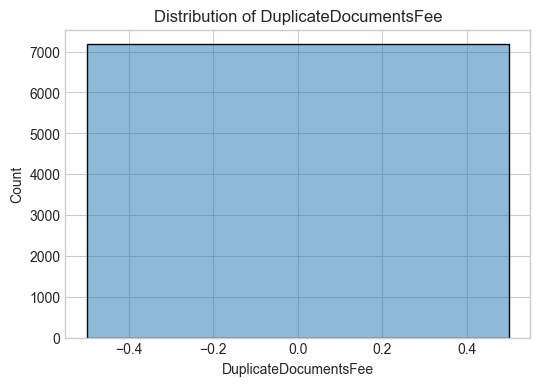

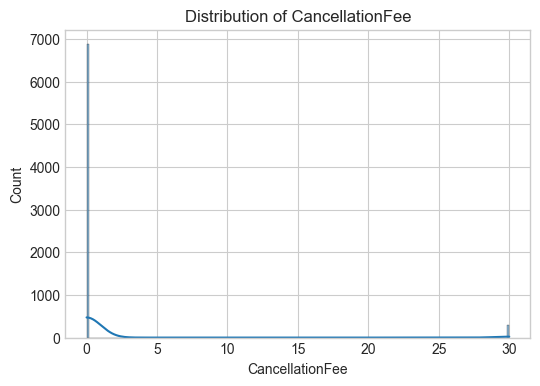

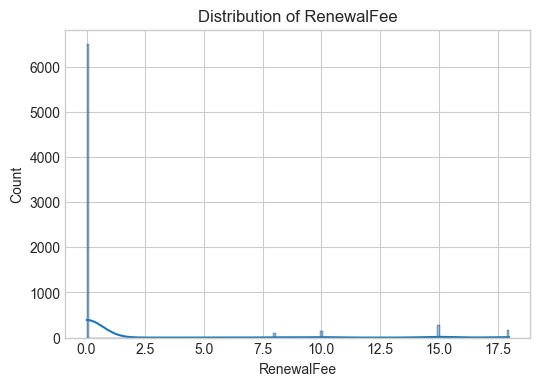

In [25]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Observation
AnnualPremium distribution may be right-skewed.
Fees such as setup or cancellation are likely fixed values.

riskid
FIX3946    3951
23500       244
52186       241
73900       241
73882       240
52195       240
73893       237
52194       231
73883       229
73889       227
52189       216
52196       215
52192       153
52187       143
23485       110
52184       108
23486        77
73888        77
Name: count, dtype: int64
provider
Animal Friends                    600
4PawsPetInsurance                 435
TIE                               400
Waggel                            384
EveryPaw                          303
                                 ... 
PetPlanUK Ultimate Cat              3
PetPlanUK Essential Dog             2
PetPlanUK Classic Dog (4K Vet)      2
PetPlanUK Classic Dog (7K Vet)      2
PetPlanUK Ultimate Dog              2
Name: count, Length: 76, dtype: int64
species
Dog    5564
Cat    1616
Name: count, dtype: int64
claimlimit
No limit    4338
£1,000       680
£4,000       555
£2,000       519
£3,000       284
£6,000       153
£2,500       143
£1,500       130
£5,000   

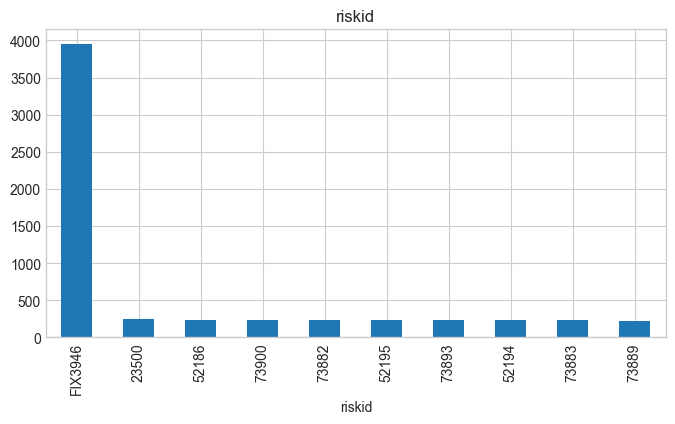

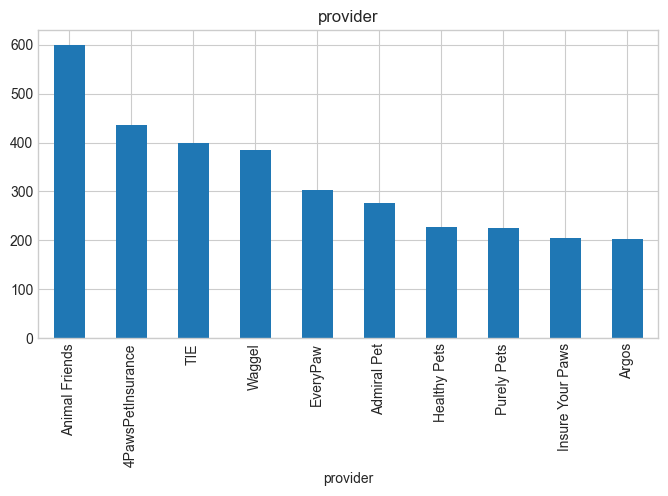

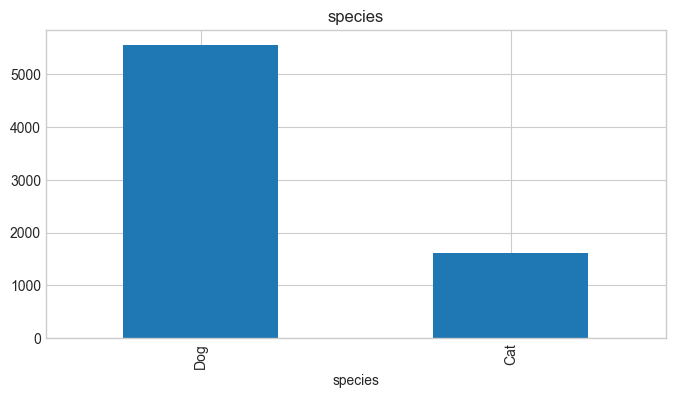

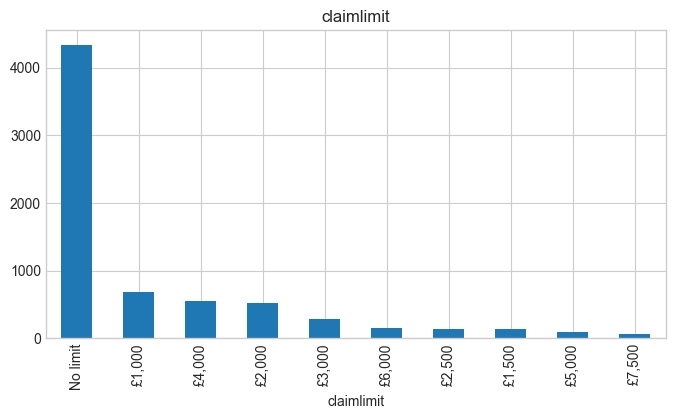

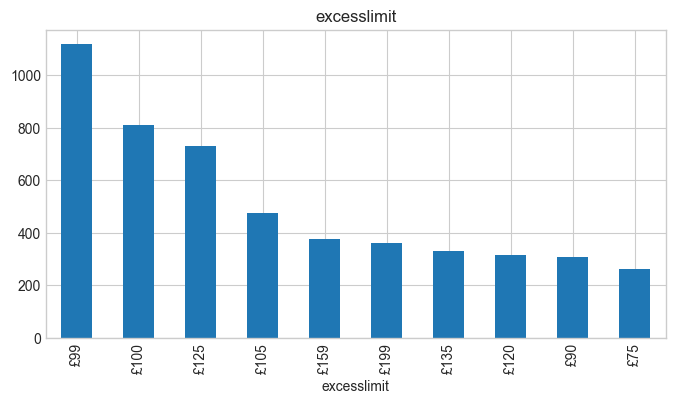

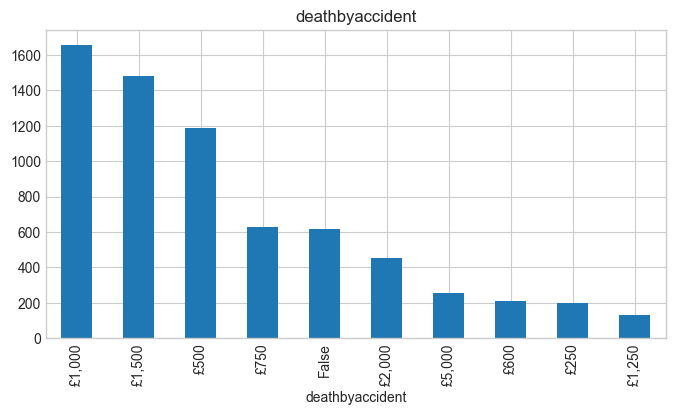

In [39]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(df[col].value_counts())


cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(df[col].value_counts())


for col in cat_cols[:6]:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
    plt.show()

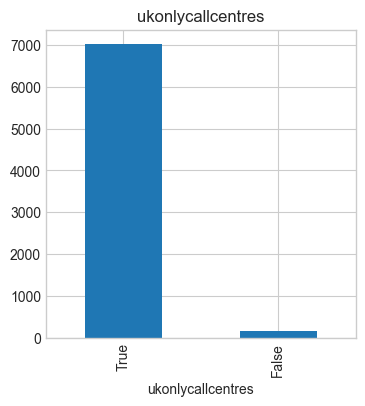

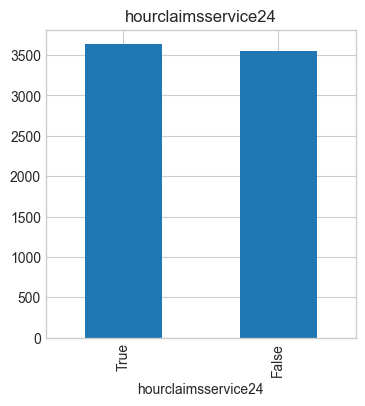

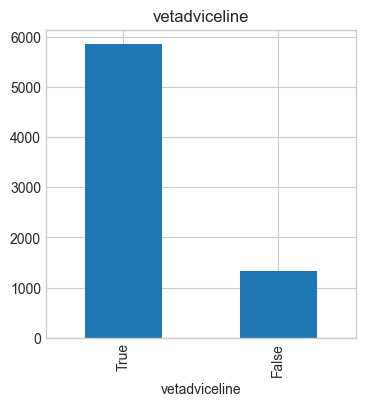

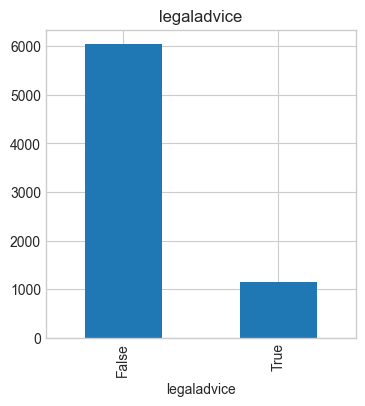

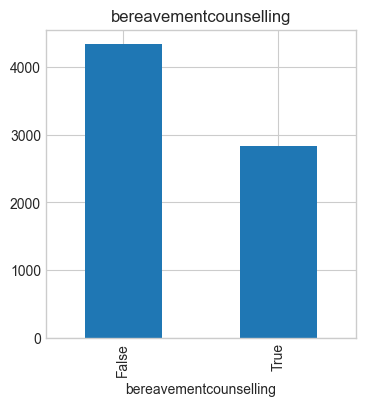

In [40]:
bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    plt.figure(figsize=(4,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

In [41]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Provider', y='AnnualPremium', data=df)
plt.xticks(rotation=90)
plt.title("Annual Premium by Provider")
plt.show()

ValueError: Could not interpret value `Provider` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

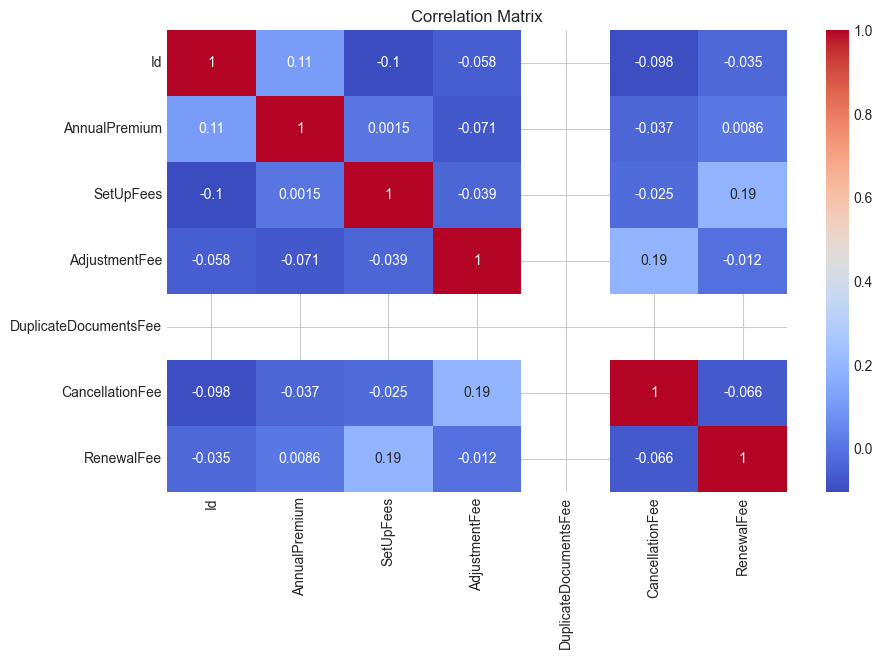

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Id', 'RiskId', 'Provider', 'Species', 'AnnualPremium', 'ClaimLimit',
       'ExcessLimit', 'UkOnlyCallCentres', 'DeathByAccident', 'BoardingFees',
       'LostOrStolen', 'AdvertisingLimit', 'HourClaimsService24',
       'VetAdviceLine', 'LegalAdvice', 'CoverStartDate',
       'BereavementCounselling', 'DeathByIllness', 'QuarantineCosts',
       'LossOfPetPassport', 'SetUpFees', 'AdjustmentFee',
       'DuplicateDocumentsFee', 'CancellationFee', 'RenewalFee', 'TimeStamp'],
      dtype='str')


In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
print(df.columns)

Index(['id', 'riskid', 'provider', 'species', 'annualpremium', 'claimlimit',
       'excesslimit', 'ukonlycallcentres', 'deathbyaccident', 'boardingfees',
       'lostorstolen', 'advertisinglimit', 'hourclaimsservice24',
       'vetadviceline', 'legaladvice', 'coverstartdate',
       'bereavementcounselling', 'deathbyillness', 'quarantinecosts',
       'lossofpetpassport', 'setupfees', 'adjustmentfee',
       'duplicatedocumentsfee', 'cancellationfee', 'renewalfee', 'timestamp'],
      dtype='str')


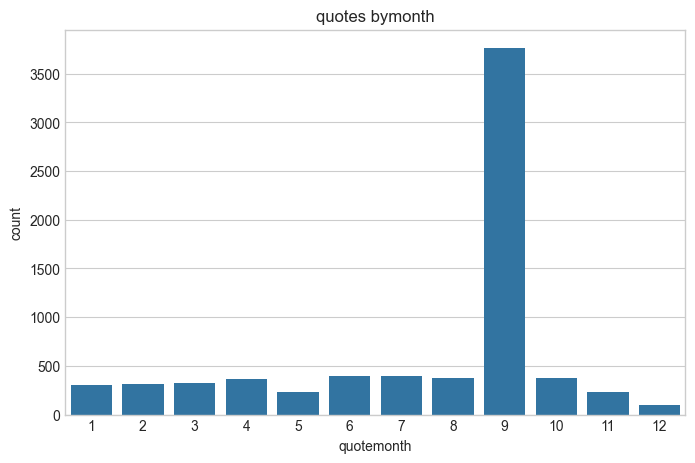

In [ ]:
df['quotemonth'] = df['timestamp'].dt.month

plt.figure(figsize=(8,5))
sns.countplot(x='quotemonth', data=df)
plt.title("quotes bymonth")
plt.show()

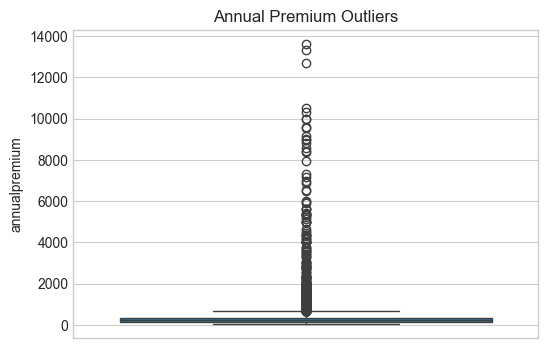

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(df['annualpremium'])
plt.title("Annual Premium Outliers")
plt.show()

In [42]:
key_findings = [
"The dataset contains 7,180 pet insurance quote records.",
"Dog insurance premiums are generally higher than cat premiums.",
"Premium prices vary across different insurance providers.",
"Many policies offer additional services such as 24-hour claims support and veterinary advice.",
"Some payment-related columns contain missing values, especially installment fields.",
"Higher annual premiums usually result in higher monthly installment payments."
]

for i, finding in enumerate(key_findings, 1):
    print(f"{i}. {finding}")

1. The dataset contains 7,180 pet insurance quote records.
2. Dog insurance premiums are generally higher than cat premiums.
3. Premium prices vary across different insurance providers.
4. Many policies offer additional services such as 24-hour claims support and veterinary advice.
5. Some payment-related columns contain missing values, especially installment fields.
6. Higher annual premiums usually result in higher monthly installment payments.
